In [14]:
# uncomment this if running on colab
#from google.colab import drive
#drive.mount('/content/drive')

In [1]:
#from __future__ import division # uncomment this if using Python 2.7
import numpy as np
import math
from scipy import signal, spatial
import matplotlib.pyplot as plt
from matplotlib import cm
from skimage import data, color, img_as_float, img_as_ubyte, filters, feature, util, io
from sklearn import metrics

%matplotlib inline
from IPython.display import HTML, display

# Feature matching



In this lab we are going to dive deeper into <i>image matching</i>, specifically on a local approach based on features correspondances.

We first consider the simplest situation possible: the image pairs we consider are related by simple transformations, therefore we will make the following choices:
1. Feature detector: corners (with the shi-tomasi algorithm)
2. Feature description: patches around the corner (size $w\times w$)
3. Matching strategy: affinity matrix with a similarity measure of choice


The parameters of every intermediate step, must be specified as input arguments. Consider all three image pairs (Rubik, Shrub, Phone)

## Let us define the main functions

<tt> patch_descriptor </tt>  extracts patches of image around each corner (w.r.t. the patch size, that is a parameter)
* First we need to pad our image, adding a surrounding frame of appropriate width. In this way even border features (like the red one in the drawing) will have their neighbourhood

Then, for each corner,
* we adjust the corner coordinates with respect to the new padded image I_ext
* we extract the size_w X size_w patch surrounding the corner (check the range notation)
* we flatten the patch to form a 1D feature vector of size 2*size_w and save it in a list



In [2]:
def patch_descriptor(I, corner_pos, size_w):
  # Extract square patches around each corner on an input grayscale image.
  # I: input image
  # corner_pos: np.array containing the (row, column) coordinates of the corners
  # size_w: (integer) patch side


    n = len(corner_pos) # Number of features
    hw = int(np.floor(size_w/2)) # half size of the patch (useful to center the pat)
    I_ext = np.pad(I, hw, 'reflect') # pad the image with a frame of width hw

    # initialize patches list
    patches = np.zeros([n,(2*hw+1)**2])

    for i in range(0, n):

        r = corner_pos[i,0]+hw # adjust the row of each corner considering the padding
        c = corner_pos[i,1]+hw # do the same for the column
        tmp = I_ext[r-hw:r+hw+1, c-hw:c+hw+1] # estract the patch
        patches[i,:] = tmp.flatten() #flatten the patch and save it in the patches list

    return patches


<tt> spectral_matching </tt> is the function that computes the feature matching procedure.
Assuming we have $m$ features in image 1 and $n$ features in image 2, the affinity matrix will have size $m\times n$.
For each feature in image 1, we will be matching the one in image 2 <i>minimizes</i> the distance.

Below you find a simple version of the procedure  
1. First compute the affinity matrix (remember it should include values in the range [0,1]
2. Then detect the maxima of the affinity matrix (both in rows and cols)
3. Derive che corresponding matches
4. Return the matches and the affinity matrix

**Hint:** First check <a href="https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.cdist.html">`spatial.distance.cdist`</a> from `scipy` module, with Euclidean metric.
You can use it to compare corners positions and/or patches :

$$\exp^{-d(f_i,g_j)/2\sigma^2}$$



In [3]:
def spectral_matching(patches1, patches2,corner_pos1,corner_pos2,sigma, alpha):
  # patches1, patches2: These are np.arrays holding the image patches around detected corners in the first and second images. They describe the visual appearance of the features.
  # corner_pos1, corner_pos2: np.arrays containing the (row, column) coordinates of the corners in the first and second images.
  # sigma: A parameter that controls the sensitivity of the matching process ( used within a Gaussian function for weighting distances).
  # alpha: A weighting factor to balance the importance of position and appearance in the matching process.

    # evaluate the distance between patches
    D = spatial.distance.cdist(patches1, patches2, metric='euclidean')
    # evaluate the distance between corners
    D_pos = spatial.distance.cdist(corner_pos1,corner_pos2, metric='euclidean')
    # compute the affinity matrix using the exponent formulation
    E1 = np.exp(-D_pos//(2*sigma*sigma)) #position
    E2 = np.exp(-D//(2*sigma*sigma))  #patches
    # by appropriate choices of alpha you may give more or less importance to the two components
    E = 0.5*(alpha*E1+(1-alpha)*E2)


    argmaxE_h = np.argmax(E, axis=1)
    argmaxE_v = np.argmax(E, axis=0)

    match = np.zeros((len(corner_pos1), 2), dtype=int)
    for i, amx in enumerate(argmaxE_h):
      if argmaxE_v[amx] == i:
        match[i] = corner_pos2[amx]

    return E, match

<tt> show_match </tt> is a function that plots the images side-by-side and superimposes the features ( notice the offset!) and a line connecting the matched pairs.

In [4]:
def show_match(match,corner_pos1,corner_pos2,img1, img2):
    """show match on side-by-side images"""

    img= np.concatenate([img1,img2],axis=1)
    plt.imshow(img, cmap=cm.gist_gray)

    for i in range(0, len(corner_pos1)):
        plt.plot([corner_pos1[i,1], match[i,1]+img1.shape[1]], [corner_pos1[i,0], match[i,0]],'y')

    plt.scatter(corner_pos1[:,1], corner_pos1[:,0], s=10, c='r')
    plt.scatter(corner_pos2[:,1]+img1.shape[1], corner_pos2[:,0], s=20, c='b')

    return img

## Let us test the feature matching pipeline

We start with a simple image pair. We first load them and visualize them

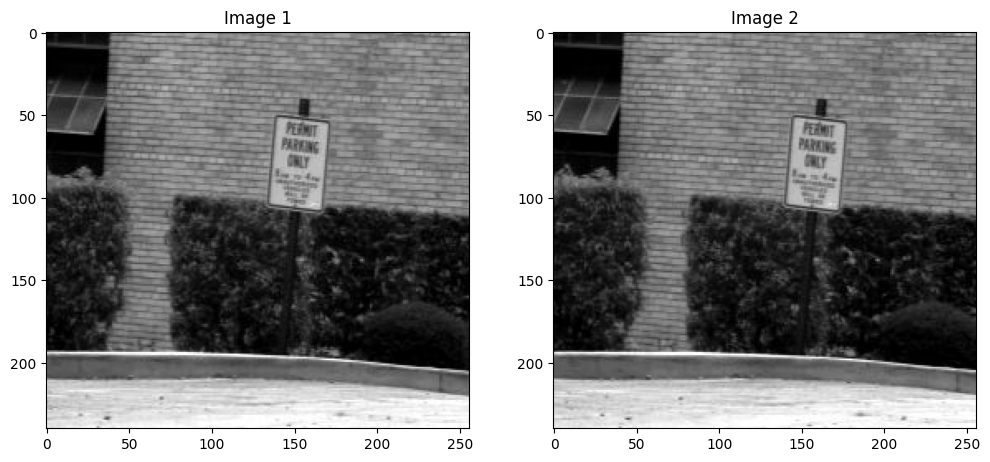

In [5]:
# LOAD IMAGES
RGBimg1 = io.imread('./images/shrub_L.jpg')
if (len(RGBimg1.shape) == 3):
    img1 = img_as_float(color.rgb2gray(RGBimg1))
else:
    img1 = img_as_float(RGBimg1)

RGBimg2 = io.imread('./images/shrub_R.jpg')
if (len(RGBimg2.shape) == 3):
    img2 = img_as_float(color.rgb2gray(RGBimg2))
else:
    img2 = img_as_float(RGBimg2)


#PLOT THEM
plt.figure(figsize=(12,6))
plt.subplot(121)
plt.imshow(RGBimg1, cmap=cm.gist_gray)
plt.title('Image 1')
plt.subplot(122)
plt.imshow(RGBimg2, cmap=cm.gist_gray)
plt.title('Image 2');


Now, let us identify the corners by using the shi tomasi algorithm implemented in skimage, <tt> corner_shi_tomasi </tt>


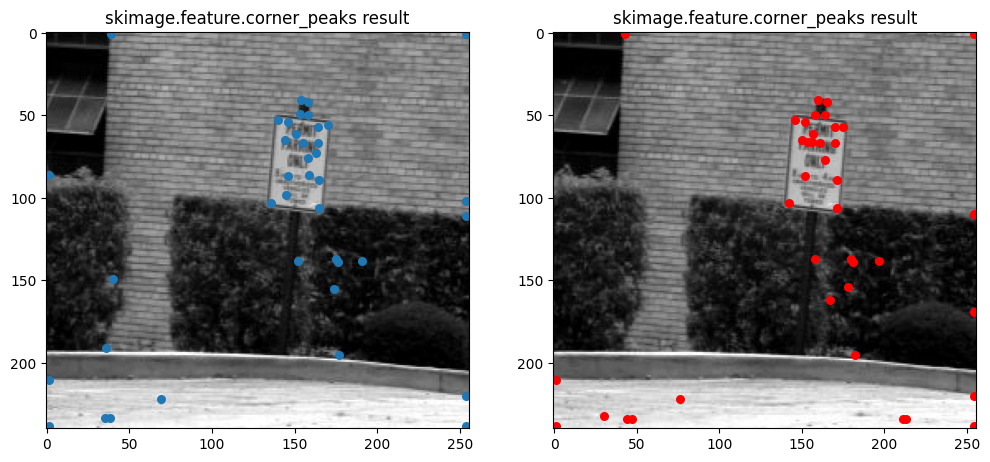

In [6]:
# FEATURE DETECTION
# using the shi-tomasi algorithm, identify the corners in both images

corners1 = feature.corner_peaks(feature.corner_shi_tomasi(img1),num_peaks=40,exclude_border=True)
corners2 = feature.corner_peaks(feature.corner_shi_tomasi(img2),num_peaks=40,exclude_border=True)

# plot the results on both images side by side
plt.figure(figsize=(12,6))
plt.subplot(121)
plt.imshow(RGBimg1, cmap=cm.gist_gray)
plt.scatter(corners1[:,1], corners1[:,0], s=30)
plt.title('skimage.feature.corner_peaks result')

plt.subplot(122)
plt.imshow(RGBimg2, cmap=cm.gist_gray)
plt.scatter(corners2[:,1], corners2[:,0], s=30, c='r')
plt.title('skimage.feature.corner_peaks result');

In [7]:
# FEATURE DESCRIPTORS
patches1 = patch_descriptor(img1, corners1, 25)
patches2 = patch_descriptor(img2, corners2, 25)

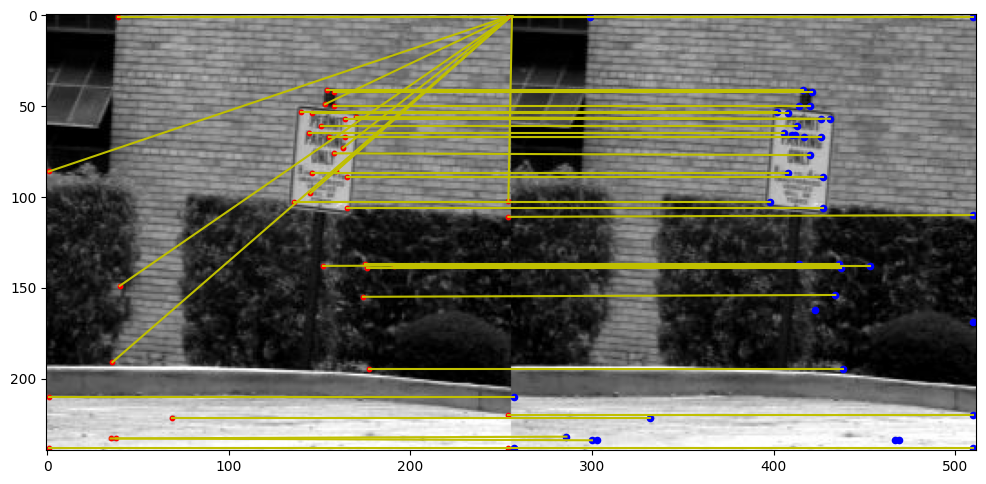

In [8]:
# FEATURE MATCHING
plt.figure(figsize=(12,6))
E,match = spectral_matching(patches1, patches2, corners1, corners2,0.9,0.2)
match_euclidean = show_match(match, corners1, corners2, RGBimg1, RGBimg2)

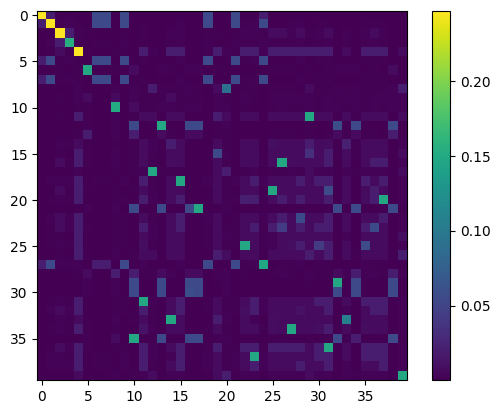

In [9]:
# LET US ALSO HAVE A LOOK AT THE AFFINITY MATRIX
plt.imshow(E)
plt.colorbar()

### Mandatory Experiments
- Debug n. 0 is to use the same image for img1 and img2. Answer before proceeding: what do you expect to find? Check the Affinity Matrix
- Now try out with two different images of the same object, again analyse the matches as well as the affinity matrix. Try out different sigma values in the <tt> spectral_matching </tt> function call : are the results in line with your expectations?  
- To be sure you fully grasp the concepts, you should try out other image pairs (see the Images folder)


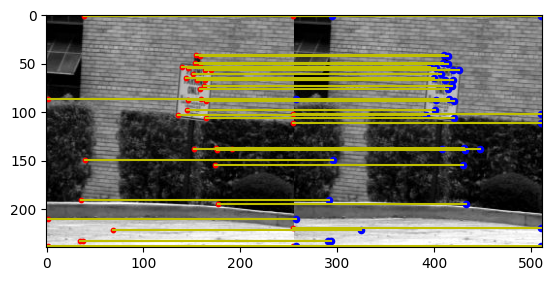

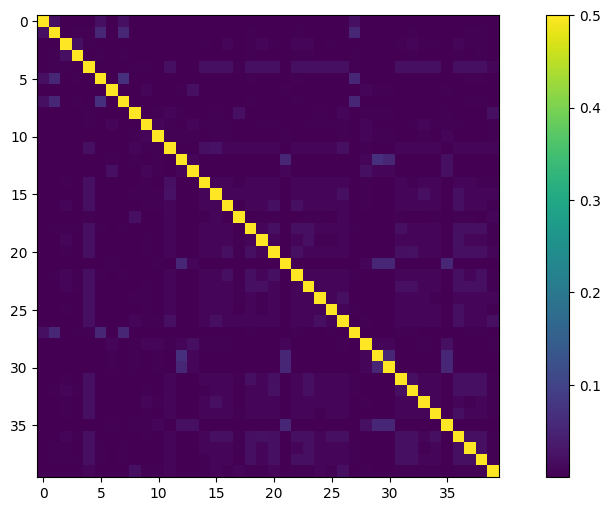

In [10]:
#EX 1
E, match = spectral_matching(patches1, patches1, corners1, corners1, 0.9, 0.2)
match_euclidean = show_match(match, corners1, corners1, RGBimg1, RGBimg1)

plt.figure(figsize=(12,6))
plt.imshow(E)
plt.colorbar()

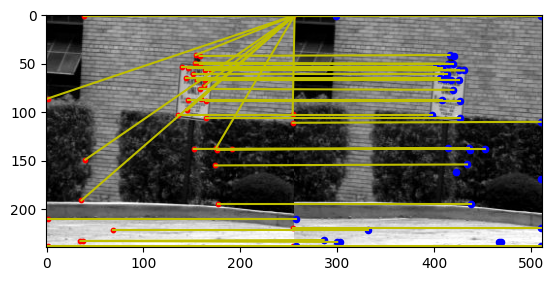

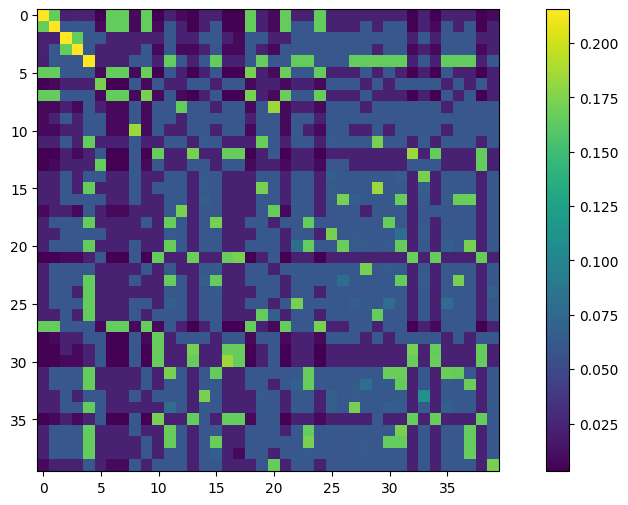

In [11]:
#EX2
E, match = spectral_matching(patches1, patches2, corners1, corners2, 1.5, 0.1)
match_euclidean = show_match(match, corners1, corners2, RGBimg1, RGBimg2)

plt.figure(figsize=(12,6))
plt.imshow(E)
plt.colorbar()

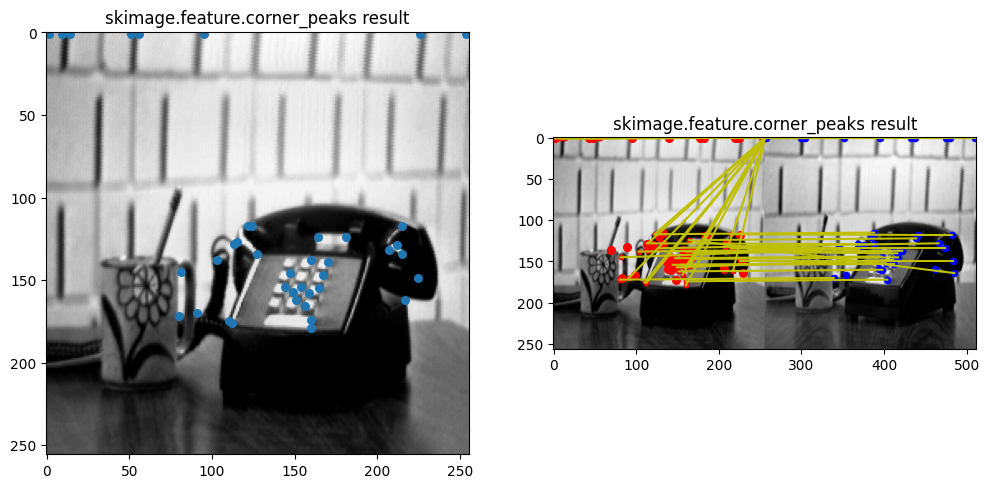

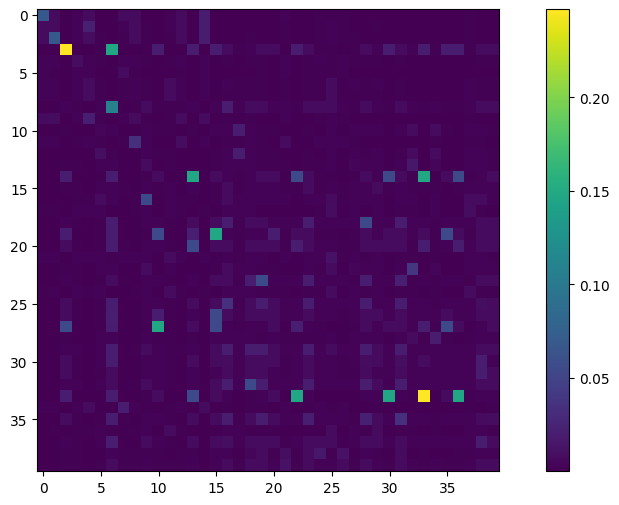

In [12]:
#EX3

RGBimg1 = io.imread('./images/phone1.png')
if (len(RGBimg1.shape) == 3):
    img1 = img_as_float(color.rgb2gray(RGBimg1))
else:
    img1 = img_as_float(RGBimg1)

RGBimg2 = io.imread('./images/phone2.png')
if (len(RGBimg2.shape) == 3):
    img2 = img_as_float(color.rgb2gray(RGBimg2))
else:
    img2 = img_as_float(RGBimg2)

corners1 = feature.corner_peaks(feature.corner_shi_tomasi(img1), num_peaks=40, exclude_border=True)
corners2 = feature.corner_peaks(feature.corner_shi_tomasi(img2), num_peaks=40, exclude_border=True)

plt.figure(figsize=(12,6))
plt.subplot(121)
plt.imshow(RGBimg1, cmap=cm.gist_gray)
plt.scatter(corners1[:,1], corners1[:,0], s=30)
plt.title('skimage.feature.corner_peaks result')

plt.subplot(122)
plt.imshow(RGBimg2, cmap=cm.gist_gray)
plt.scatter(corners2[:,1], corners2[:,0], s=30, c='r')
plt.title('skimage.feature.corner_peaks result');

patches1 = patch_descriptor(img1, corners1, 25)
patches2 = patch_descriptor(img2, corners2, 25)

E, match = spectral_matching(patches1, patches2, corners1, corners2, 0.9, 0.2)
match_euclidean = show_match(match, corners1, corners2, RGBimg1, RGBimg2)

plt.figure(figsize=(12,6))
plt.imshow(E)
plt.colorbar()

### Optional improvements
There are several improvements you could consider  
1.  Spectral_matching: you may add a threshold on the distance, setting to 0 the affinity matrix entries below a threshold(see theory)
2. Corners on the border of the image should be discarded as they tend to be less reliable.
3. The two sigmas used in appearance and position estimation in the function <tt> spectral_matching</tt> could be different
4. One may also try with different distance metrics (normalized correlation or sum of squared differences between patches)



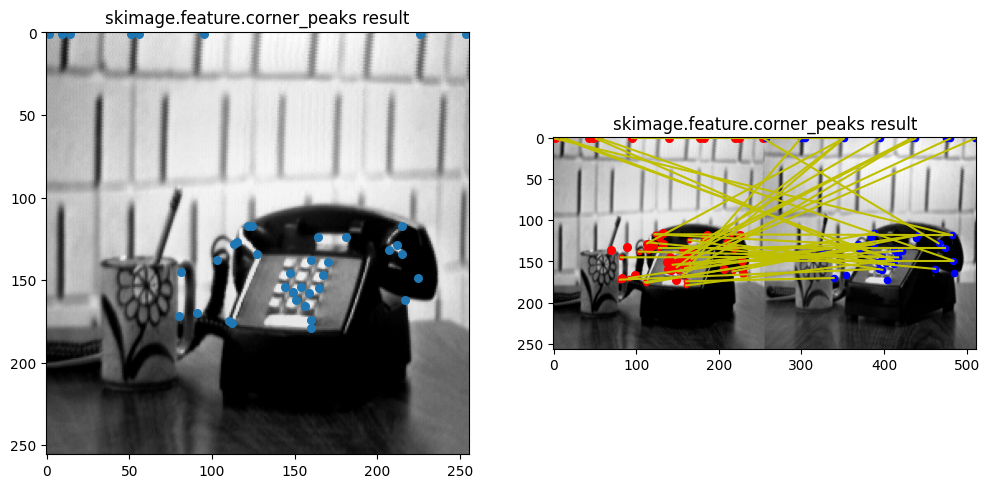

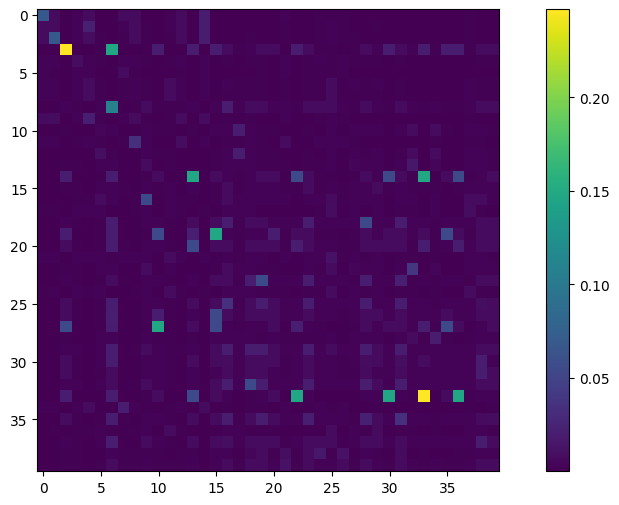

In [13]:
#EX1

def spectral_matching(patches1, patches2, corner_pos1, corner_pos2, sigma, alpha, threshold):
    D = spatial.distance.cdist(patches1, patches2, metric='euclidean')
    D_pos = spatial.distance.cdist(corner_pos1, corner_pos2, metric='euclidean')
    
    E1 = np.exp(-D_pos // (2*sigma*sigma))
    E2 = np.exp(-D // (2*sigma*sigma))

    if(E1.any() < threshold):
        E1 = 0

    if(E2.any() < threshold):
        E2 = 0

    E = 0.5 * (alpha*E1 + (1-alpha)*E2)

    argmaxE_h = np.argmax(E, axis=1)
    argmaxE_v = np.argmax(E, axis=0)
    match = []

    for i, amx in enumerate(argmaxE_h):
        if argmaxE_v[amx] == i:
            match = corner_pos2[argmaxE_v,:]

    return E, match

corners1 = feature.corner_peaks(feature.corner_shi_tomasi(img1), num_peaks=40, exclude_border=True)
corners2 = feature.corner_peaks(feature.corner_shi_tomasi(img2), num_peaks=40, exclude_border=True)

plt.figure(figsize=(12,6))
plt.subplot(121)
plt.imshow(RGBimg1, cmap=cm.gist_gray)
plt.scatter(corners1[:,1], corners1[:,0], s=30)
plt.title('skimage.feature.corner_peaks result')

plt.subplot(122)
plt.imshow(RGBimg2, cmap=cm.gist_gray)
plt.scatter(corners2[:,1], corners2[:,0], s=30, c='r')
plt.title('skimage.feature.corner_peaks result');

patches1 = patch_descriptor(img1, corners1, 25)
patches2 = patch_descriptor(img2, corners2, 25)

E, match = spectral_matching(patches1, patches2, corners1, corners2, 0.9, 0.2, 0.2)
match_euclidean = show_match(match, corners1, corners2, RGBimg1, RGBimg2)

plt.figure(figsize=(12,6))
plt.imshow(E)
plt.colorbar()